In [1]:
"""this is the second assignment of Natural language proccessing
   this was made by group 11 comprised of:
   Miruna Lungu (S5882206)
   Andrejs Tupikins (S5607442)
   Prayer Aguebor (S5901782)
"""


'this is the second assignment of Natural language proccessing\n   this was made by group 11 comprised of:\n   Miruna Lungu (S5882206)\n   Andrejs Tupikins (S5607442)\n   Prayer Aguebor (S5901782)\n'

In [20]:
import re
import html
import keras
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from datasets import load_dataset , concatenate_datasets
import tensorflow as tf
from keras import regularizers
from keras.callbacks import EarlyStopping
from keras.models import Model, Sequential
from keras.layers import (
    Input, Embedding, Conv1D,
    GlobalMaxPooling1D,Dense,
    Dropout, BatchNormalization,
    Concatenate, Activation, 
    Bidirectional , LSTM, GlobalAveragePooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

target_names = ["World", "Sports", "Business", "Sci/Tech"]


In [33]:
news_dataset = load_dataset("ag_news")
full_dataset = concatenate_datasets([
    news_dataset["train"],
    news_dataset["test"]
])

In [34]:
split = full_dataset.train_test_split(test_size=0.3, seed=42)
train_data = split["train"]
val_test_data = split["test"]
test_valid = val_test_data.train_test_split(test_size=0.5, seed=42)

In [35]:
"""data split into 70% train 15% validation 15% test """
val_data = test_valid["train"]
test_data = test_valid["test"]


In [36]:
# training data
train_text = train_data["text"]
train_label = train_data["label"]

# validation data
val_text = val_data["text"]
val_label = val_data["label"]

# used at the end for testing
test_text = test_data["text"]
test_label = test_data["label"]

In [37]:
ABBREVIATIONS = {
    r"\b(?:US|U\.S\.?)\b": "America",
    r"\b(?:EU|E\.U\.?)\b": "European Union",
    r"\b(?:U\.K\.?|UK)\b": "United Kingdom",
    r"\b(?:U\.S\.A\.?|USA)\b": "United States of America",
    r"\b(?:UN|U\.N\.?)\b": "United Nations",
    r"\b(?:NATO)\b": "North Atlantic Treaty Organization",
    r"\b(?:IMF)\b": "International Monetary Fund",
}

CONTRACTIONS = {
    r"won\s*['’]t": "will not",
    r"can\s*['’]t": "can not",
    r"shan\s*['’]t": "shall not",
    r"should\s*['’]t": "should not",
    r"was\s*['’]t": "was not",
    r"is\s*['’]t": "is not",
    r"what\s*['’]s": "what is",
    r"that\s*['’]s": "that is",
    r"he\s*['’]s": "he is",
    r"she\s*['’]s": "she is",
    r"it\s*['’]s": "it is",
    r"i\s*['’]m": "i am",
    r"(\w+)\s*['’]ve": r"\1 have",
    r"(\w+)\s*['’]re": r"\1 are",
    r"(\w+)\s*['’]ll": r"\1 will",
    r"(\w+)\s*['’]d": r"\1 would",
    r"(\w+)\s*n't": r"\1 not",
}

def preProcessing(text):
    # Fix broken HTML entities
    text = re.sub(r"(?<!&)#(\d+);", r"&#\1;", text)
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text()
    for pattern, full_name in ABBREVIATIONS.items():
        text = re.sub(pattern, full_name, text, flags=re.IGNORECASE)
    for pattern, repl in CONTRACTIONS.items():
        text = re.sub(pattern, repl, text, flags=re.I)
    text = text.lower()
    
    # Step 1: normalize million/billion/thousand
    text = re.sub(r'(\d+(?:\.\d+)?)\s*million', r'\1m', text, flags=re.I)
    text = re.sub(r'(\d+(?:\.\d+)?)\s*billion', r'\1b', text, flags=re.I)
    text = re.sub(r'(\d+(?:\.\d+)?)\s*thousand', r'\1k', text, flags=re.I)
    text = re.sub(r'\d+(?:\.\d+)?', '<num>', text)

    url_pattern = re.compile(r"https?://\S+|www\.\S+")
    text = url_pattern.sub("", text)
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\b(\w+)\s+'s\b", r"\1's", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


train_text = [preProcessing(text) for text in train_text]
val_text = [preProcessing(text) for text in val_text]
test_text = [preProcessing(text) for text in test_text]

In [8]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_text)
vocab_size = len(tokenizer.word_index) + 1

sequences_train = tokenizer.texts_to_sequences(train_text)
sequences_val = tokenizer.texts_to_sequences(val_text)
max_len= max(len(seq) for seq in sequences_train)

# Pad sequences to ensure uniform input size
train_sequences = pad_sequences(sequences_train, padding='post', maxlen=max_len)
val_sequences = pad_sequences(sequences_val, padding='post', maxlen=max_len)

# Convert labels to a numpy array
train_labels = np.array(train_label, dtype=np.float32)
val_labels = np.array(val_label, dtype=np.float32)


In [9]:
conv_blocks = []
embedding_dim = 50
num_filters = 64
number_class = 4
tf.random.set_seed(42)

early_stopping_cnn = EarlyStopping(
    monitor="val_loss", 
    patience=1, 
    restore_best_weights=True
)

inputs = Input(shape=(max_len,))
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)

for kernel_size in [3, 4, 5, 6]:
    conv = Conv1D(
        num_filters, 
        kernel_size, 
        padding="same",
        kernel_regularizer=regularizers.l2(0.1)
        )(x)
    conv = BatchNormalization()(conv)
    conv = Activation("relu")(conv)
    conv = Dropout(0.5)(conv)
    conv = GlobalMaxPooling1D()(conv)
    conv_blocks.append(conv)

x = Concatenate()(conv_blocks)
x = Dense(32, activation="relu")(x)
outputs = Dense(number_class, activation="softmax")(x)
cnn_model = Model(inputs, outputs)

optimize_cnn = keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-2)
cnn_model.compile(
    optimizer=optimize_cnn, loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    train_sequences, 
    train_labels, epochs=10,
    validation_data=(val_sequences, val_labels),
    callbacks=[early_stopping_cnn]
)

Epoch 1/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 58s 20ms/step - accuracy: 0.7010 - loss: 5.5902 - val_accuracy: 0.8908 - val_loss: 0.7973
Epoch 2/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 104s 37ms/step - accuracy: 0.8988 - loss: 0.4342 - val_accuracy: 0.9083 - val_loss: 0.4729
Epoch 3/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 60s 21ms/step - accuracy: 0.9205 - loss: 0.2993 - val_accuracy: 0.9126 - val_loss: 0.4028
Epoch 4/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 61s 22ms/step - accuracy: 0.9343 - loss: 0.2461 - val_accuracy: 0.9139 - val_loss: 0.3583
Epoch 5/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 56s 20ms/step - accuracy: 0.9465 - loss: 0.2074 - val_accuracy: 0.9148 - val_loss: 0.3365
Epoch 6/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 165s 59ms/step - accuracy: 0.9565 - loss: 0.1769 - val_accuracy: 0.9127 - val_loss: 0.3257
Epoch 7/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 123s 44ms/step - accuracy: 0.9649 - loss: 0.1516 - val_accuracy: 0.9116 - val_loss: 0.3204
Epoch 8/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 201s 72ms/step - accuracy: 0.97

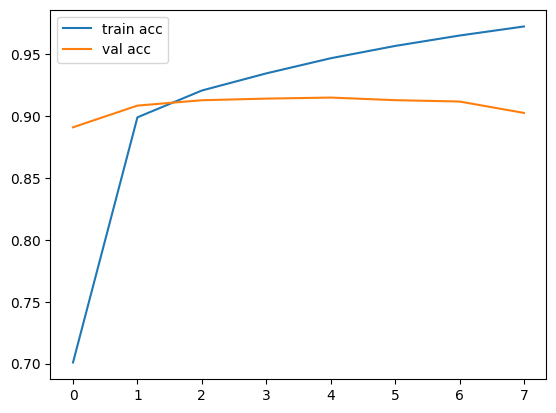

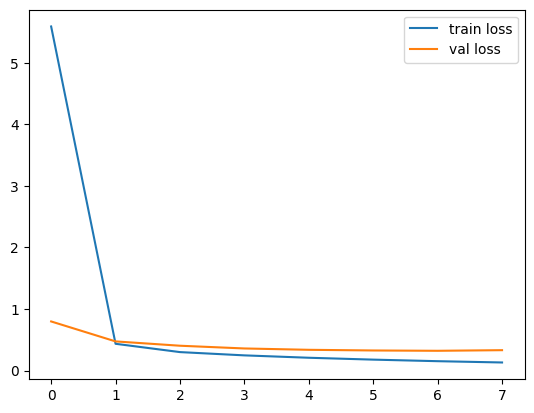

In [10]:
plt.plot(history_cnn.history["accuracy"], label="train acc")
plt.plot(history_cnn.history["val_accuracy"], label="val acc")
plt.legend()
plt.show()

plt.plot(history_cnn.history["loss"], label="train loss")
plt.plot(history_cnn.history["val_loss"], label="val loss")
plt.legend()
plt.show()

In [11]:
test_sequences = tokenizer.texts_to_sequences(test_text)
test_padded = pad_sequences(test_sequences, maxlen=max_len)

predictions_cnn = cnn_model.predict(test_padded)
test_pred_cnn = np.argmax(predictions_cnn, axis=1)

print(
    classification_report(
        test_label, test_pred_cnn, target_names=target_names, digits=4
    )
)

599/599 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

       World     0.9067    0.9137    0.9102      4901
      Sports     0.9578    0.9671    0.9624      4768
    Business     0.8939    0.8633    0.8783      4741
    Sci/Tech     0.8802    0.8947    0.8874      4730

    accuracy                         0.9098     19140
   macro avg     0.9096    0.9097    0.9096     19140
weighted avg     0.9097    0.9098    0.9097     19140



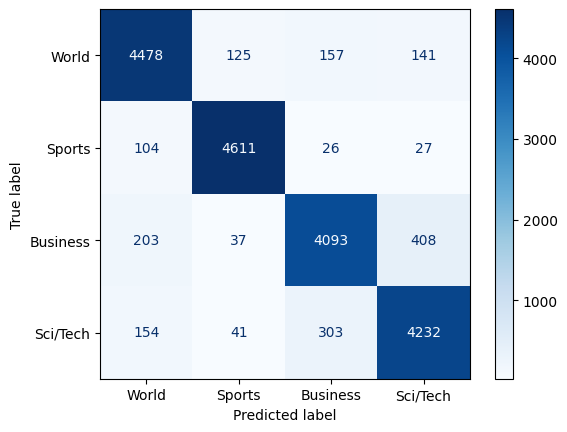

In [12]:
ConfusionMatrixDisplay.from_predictions(
    test_label, test_pred_cnn, display_labels=target_names, cmap="Blues"
)


In [13]:
mis_idx = [i for i in range(len(test_label)) if test_label[i] != test_pred_cnn[i]]
misclassified_examples_cnn = []

for i in mis_idx[:20]:  # take first 20
    misclassified_examples_cnn.append(
        {
            "text": test_text[i],
            "true": target_names[test_label[i]],
            "pred": target_names[test_pred_cnn[i]],
        }
    )
df_errors = pd.DataFrame(misclassified_examples_cnn)
df_errors.head(20)


,text,true,pred
0,major peoplesoft investor will not tender shar...,Sci/Tech,Business
1,netflix tivo sign vod alliance netflix the onl...,Business,Sci/Tech
2,digital agenda homeland security roundtable is...,Sci/Tech,Business
3,peoplesoft reviews european union approval of ...,Business,Sci/Tech
4,hopes of malaria vaccine by num scientists say...,World,Sci/Tech
5,president signs american jobs creation act was...,Sci/Tech,Business
6,china hands out quot green card quot winning a...,World,Sci/Tech
7,intel nvidia sign cross licensing pact chip gi...,Business,Sci/Tech
8,your personal data is often at risk as ken sol...,Sci/Tech,Business
9,bcci says sony to telecast australia test seri...,World,Sci/Tech


In [43]:
forward = LSTM(
    100,
    dropout=0.15,
    recurrent_dropout=0.15,
    return_sequences=True,
)

backward = LSTM(
    100,
    dropout=0.15,
    recurrent_dropout=0.15,
    return_sequences=True,
    go_backwards=True
)

lstm_model = Sequential(
    [
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
        ),
        Bidirectional(forward , backward_layer= backward),
        GlobalAveragePooling1D(),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(number_class, activation="softmax"),
    ]
)

optimize_lstm = keras.optimizers.Adam(learning_rate=1e-3)
lstm_model.compile(
    optimizer=optimize_lstm, 
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_lstm = EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True
)

history_lstm = lstm_model.fit(
    train_sequences, 
    train_labels, 
    epochs=10, 
    validation_data=(val_sequences, val_labels),
    callbacks=[early_stopping_lstm],
    batch_size=32
)


Epoch 1/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 1065s 380ms/step - accuracy: 0.7559 - loss: 0.6052 - val_accuracy: 0.9098 - val_loss: 0.2810
Epoch 2/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 1012s 362ms/step - accuracy: 0.9212 - loss: 0.2633 - val_accuracy: 0.9174 - val_loss: 0.2582
Epoch 3/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 966s 346ms/step - accuracy: 0.9424 - loss: 0.1931 - val_accuracy: 0.9138 - val_loss: 0.2851
Epoch 4/10
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 977s 350ms/step - accuracy: 0.9551 - loss: 0.1438 - val_accuracy: 0.9119 - val_loss: 0.3059


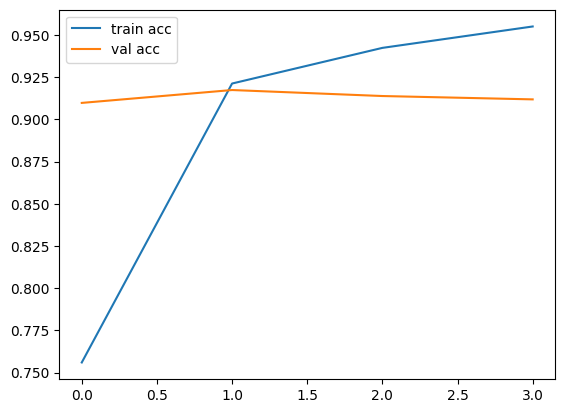

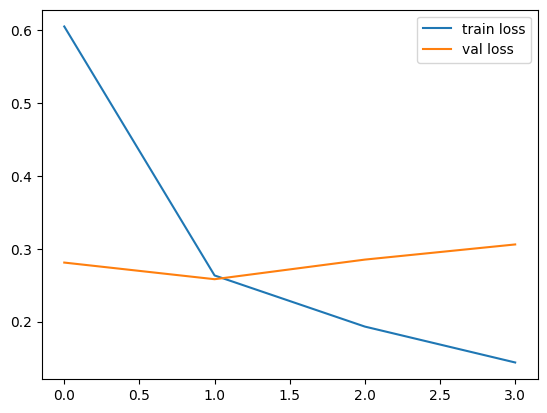

In [44]:
plt.plot(history_lstm.history["accuracy"], label="train acc")
plt.plot(history_lstm.history["val_accuracy"], label="val acc")
plt.legend()
plt.show()

plt.plot(history_lstm.history["loss"], label="train loss")
plt.plot(history_lstm.history["val_loss"], label="val loss")
plt.legend()
plt.show()


In [45]:
predictions_lstm = lstm_model.predict(test_padded)
test_pred_lstm = np.argmax(predictions_lstm, axis=1)

print(
    classification_report(
        test_label, test_pred_lstm, target_names=target_names, digits=4
    )
)


599/599 ━━━━━━━━━━━━━━━━━━━━ 55s 91ms/step
              precision    recall  f1-score   support

       World     0.9169    0.9033    0.9101      4901
      Sports     0.9632    0.9715    0.9673      4768
    Business     0.9075    0.8551    0.8805      4741
    Sci/Tech     0.8650    0.9209    0.8921      4730

    accuracy                         0.9127     19140
   macro avg     0.9132    0.9127    0.9125     19140
weighted avg     0.9133    0.9127    0.9126     19140



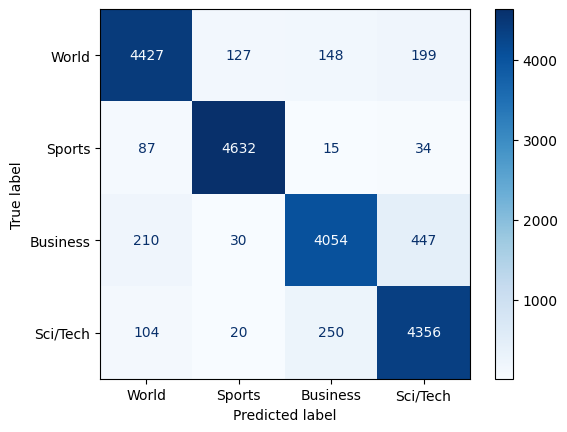

In [46]:
ConfusionMatrixDisplay.from_predictions(
    test_label, test_pred_lstm, display_labels=target_names, cmap="Blues"
)


In [ ]:
mis_idx = [i for i in range(len(test_label)) if test_label[i] != test_pred_lstm[i]]
misclassified_examples_lstm = []

for i in mis_idx[:20]:  # take first 20
    misclassified_examples_lstm.append(
        {
            "text": test_text[i],
            "true": target_names[test_label[i]],
            "pred": target_names[test_pred_lstm[i]],
        }
    )
df_errors = pd.DataFrame(misclassified_examples_lstm)
df_errors.head(20)


,text,true,pred
0,major peoplesoft investor will not tender shar...,Sci/Tech,Business
1,blair delays pensions move until after poll to...,Business,World
2,the price paid for blood on a child prosecutor...,World,Sports
3,netflix tivo sign vod alliance netflix the onl...,Business,Sci/Tech
4,digital agenda homeland security roundtable is...,Sci/Tech,Business
5,hopes of malaria vaccine by num scientists say...,World,Sci/Tech
6,study stability control systems can reduce fat...,Business,Sci/Tech
7,president signs american jobs creation act was...,Sci/Tech,Business
8,china hands out quot green card quot winning a...,World,Sci/Tech
9,intel nvidia sign cross licensing pact chip gi...,Business,Sci/Tech
